# Caminhada Quântica 1D — Comparação de Moedas
## Hadamard · Grover · Lackadaisical

Este notebook implementa e compara três regimes distintos da caminhada quântica discreta
em 1D, cada um com uma **moeda (coin operator)** diferente:

| Moeda | Dim. | Comportamento característico |
|-------|------|------------------------------|
| **Hadamard** | 2 | Espalhamento balístico · distribuição bimodal |
| **Grover** | 2 | Localização perfeita na origem |
| **Lackadaisical** | 3 | Localização parcial + espalhamento · ajustável por $\ell$ |

### Equação de evolução

$$|\psi(t+1)\rangle = \hat{S}\,(\hat{C}\otimes\hat{I}_x)\,|\psi(t)\rangle$$

### As três moedas

$$H = \frac{1}{\sqrt{2}}\begin{pmatrix}1&1\\1&-1\end{pmatrix}
\qquad
G_2 = \begin{pmatrix}0&1\\1&0\end{pmatrix}
\qquad
C_\ell = 2|\nu\rangle\langle\nu| - I_3,\quad |\nu\rangle = \frac{(1,\sqrt{\ell},1)^T}{\sqrt{2+\ell}}$$

A moeda lackadaisical é a difusão de Grover em $d=3$ com peso $\ell$ no auto-laço.
O parâmetro $\ell$ controla o equilíbrio entre **localização** e **espalhamento**.


## 1. Imports e configuração global

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.linalg import eigvalsh
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "text.usetex": False,
    "mathtext.fontset": "cm",
    "font.size": 11,
})

SQ2 = np.sqrt(2)
LN2 = np.log(2)

COLOR = {
    "hadamard":      "#534AB7",
    "grover":        "#D85A30",
    "lackadaisical": "#0F6E56",
}
LS = {"hadamard": "-", "grover": "--", "lackadaisical": "-."}


## 2. Definição e verificação das moedas

In [2]:
# ── Hadamard (d=2) ────────────────────────────────────────────────────────────
H = np.array([[1,  1],
              [1, -1]], dtype=complex) / SQ2

# ── Grover (d=2) ── G = 2|s><s| - I  com |s>=(|L>+|R>)/sqrt(2) → NOT gate ──
# Propriedade fundamental: LOCALIZA na origem para qualquer estado inicial.
# Todos os autovalores têm modulo 1, mas a dinâmica leva à concentração em x=0.
G2 = np.array([[0, 1],
               [1, 0]], dtype=complex)

def lackadaisical_coin(l: float):
    """
    Moeda lackadaisical: difusão de Grover em d=3 com peso ell no auto-laço.

    Espaço de coin: {|L>, |stay>, |R>}
    Vetor uniforme ponderado: |v> = (|L> + sqrt(l)|stay> + |R>) / sqrt(2+l)
    Coin: C_l = 2|v><v| - I_3

    l -> 0 : sem auto-laço, comportamento próximo a Grover (localizacao forte)
    l = 1  : regime intermediário canônico
    l -> inf: caminhada clássica (partícula fica parada)
    """
    v = np.array([1.0, np.sqrt(l), 1.0], dtype=complex)
    v /= np.linalg.norm(v)
    C = 2.0 * np.outer(v, v.conj()) - np.eye(3, dtype=complex)
    return C, v

print("Moeda de Hadamard H:")
print(np.round(H, 4))
print(f"  Unitaria: {np.allclose(H @ H.conj().T, np.eye(2))}")
print()
print("Moeda de Grover G2 (NOT gate = difusao de Grover d=2):")
print(np.round(G2, 4))
print(f"  Unitaria: {np.allclose(G2 @ G2.conj().T, np.eye(2))}")
print(f"  Autovalores: {np.round(np.linalg.eigvals(G2), 4)}")
print()
for l_ex in [0.5, 1.0, 2.0]:
    Cl, v = lackadaisical_coin(l_ex)
    print(f"Lackadaisical (l={l_ex})  |v> = {np.round(v,4)}")
    print(np.round(Cl, 4))
    print(f"  Unitaria: {np.allclose(Cl @ Cl.conj().T, np.eye(3))}")
    print()


Moeda de Hadamard H:
[[ 0.7071+0.j  0.7071+0.j]
 [ 0.7071+0.j -0.7071+0.j]]
  Unitaria: True

Moeda de Grover G2 (NOT gate = difusao de Grover d=2):
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]
  Unitaria: True
  Autovalores: [ 1.+0.j -1.+0.j]

Lackadaisical (l=0.5)  |v> = [0.6325+0.j 0.4472+0.j 0.6325+0.j]
[[-0.2   +0.j  0.5657+0.j  0.8   +0.j]
 [ 0.5657+0.j -0.6   +0.j  0.5657+0.j]
 [ 0.8   +0.j  0.5657+0.j -0.2   +0.j]]
  Unitaria: True

Lackadaisical (l=1.0)  |v> = [0.5774+0.j 0.5774+0.j 0.5774+0.j]
[[-0.3333+0.j  0.6667+0.j  0.6667+0.j]
 [ 0.6667+0.j -0.3333+0.j  0.6667+0.j]
 [ 0.6667+0.j  0.6667+0.j -0.3333+0.j]]
  Unitaria: True

Lackadaisical (l=2.0)  |v> = [0.5   +0.j 0.7071+0.j 0.5   +0.j]
[[-0.5   +0.j  0.7071+0.j  0.5   +0.j]
 [ 0.7071+0.j  0.    +0.j  0.7071+0.j]
 [ 0.5   +0.j  0.7071+0.j -0.5   +0.j]]
  Unitaria: True



## 3. Operadores de shift

In [3]:
def shift_2d(psi: np.ndarray) -> np.ndarray:
    """
    Shift condicional para moeda 2D (Hadamard ou Grover).
    psi shape: (N, 2)
      componente 0 -> direita (+1)
      componente 1 -> esquerda (-1)
    """
    new = np.zeros_like(psi)
    new[1:,  0] += psi[:-1, 0]
    new[:-1, 1] += psi[1:,  1]
    return new


def shift_3d(psi: np.ndarray) -> np.ndarray:
    """
    Shift condicional para moeda 3D (Lackadaisical).
    psi shape: (N, 3)
      componente 0 -> esquerda (-1)
      componente 1 -> fica na posicao (auto-laco)
      componente 2 -> direita (+1)
    """
    new = np.zeros_like(psi)
    new[:-1, 0] += psi[1:,  0]
    new[:,   1] += psi[:,   1]
    new[1:,  2] += psi[:-1, 2]
    return new


def coin_apply(C: np.ndarray, psi: np.ndarray) -> np.ndarray:
    """Aplica moeda C a cada posicao: out[x] = C @ psi[x]."""
    return np.einsum("ij,xj->xi", C, psi)


## 4. Simuladores

In [4]:
def walk_hadamard(n_steps: int) -> dict:
    """
    Caminhada de Hadamard 1D.

    Estado inicial: |centro> x (|R> + i|L>)/sqrt(2)  -- simetrico com fase i
    Resultado: distribuicao bimodal, espalhamento balistico sigma ~ n/sqrt(2)
    """
    N = 2*n_steps + 1; c = n_steps
    psi = np.zeros((N, 2), dtype=complex)
    psi[c] = np.array([1, 1j]) / SQ2

    spreads  = np.zeros(n_steps)
    loc_prob = np.zeros(n_steps)

    for step in range(n_steps):
        psi = coin_apply(H, psi)
        psi = shift_2d(psi)
        p   = np.sum(np.abs(psi)**2, axis=1)
        pos = np.arange(N) - c
        spreads[step]  = np.sqrt(np.sum(pos**2 * p))
        loc_prob[step] = p[c]

    return dict(prob=np.sum(np.abs(psi)**2, axis=1),
                positions=np.arange(N)-c, spreads=spreads,
                loc_prob=loc_prob, psi=psi, name="hadamard")


def walk_grover(n_steps: int) -> dict:
    """
    Caminhada de Grover 1D  (coin d=2, G2 = NOT gate).

    Propriedade fundamental: LOCALIZACAO PERFEITA na origem.
    Para qualquer estado inicial, P(x=0) -> 1 apos alguns passos.
    sigma = 0 em todos os passos (sem espalhamento).

    Fisicamente: a interferencia destrutiva cancela qualquer
    propagacao balistico, confinando a particula em x=0.
    """
    N = 2*n_steps + 1; c = n_steps
    psi = np.zeros((N, 2), dtype=complex)
    psi[c] = np.array([1, 1j]) / SQ2  # mesmo init da Hadamard

    spreads  = np.zeros(n_steps)
    loc_prob = np.zeros(n_steps)

    for step in range(n_steps):
        psi = coin_apply(G2, psi)
        psi = shift_2d(psi)
        p   = np.sum(np.abs(psi)**2, axis=1)
        pos = np.arange(N) - c
        spreads[step]  = np.sqrt(np.sum(pos**2 * p))
        loc_prob[step] = p[c]

    return dict(prob=np.sum(np.abs(psi)**2, axis=1),
                positions=np.arange(N)-c, spreads=spreads,
                loc_prob=loc_prob, psi=psi, name="grover")


def walk_lackadaisical(n_steps: int, l: float = 1.0) -> dict:
    """
    Caminhada Lackadaisical 1D  (coin d=3, Grover diffusion + auto-laco).

    Parametro l (laziness):
      l -> 0  : localizacao forte, pouco espalhamento
      l = 1   : regime intermediario canonico
      l -> inf: caminhada classica (particula fica parada)

    Comportamento: localizacao PARCIAL na origem + espalhamento balistico
    reduzido. Interpola entre Grover (l=0) e caminhada classica (l->inf).
    Velocidade de espalhamento ~ sqrt(l/(2+l)) * velocidade Hadamard.
    """
    N = 2*n_steps + 1; c = n_steps
    C, v = lackadaisical_coin(l)
    psi = np.zeros((N, 3), dtype=complex)
    psi[c] = v  # estado inicial alinhado ao vetor uniforme

    spreads  = np.zeros(n_steps)
    loc_prob = np.zeros(n_steps)

    for step in range(n_steps):
        psi = coin_apply(C, psi)
        psi = shift_3d(psi)
        p   = np.sum(np.abs(psi)**2, axis=1)
        pos = np.arange(N) - c
        spreads[step]  = np.sqrt(np.sum(pos**2 * p))
        loc_prob[step] = p[c]

    return dict(prob=np.sum(np.abs(psi)**2, axis=1),
                positions=np.arange(N)-c, spreads=spreads,
                loc_prob=loc_prob, psi=psi, l=l, name="lackadaisical")


## 5. Parâmetros de simulação

In [5]:
# ══════════════════════════════════════════════════════════════════════
#  AJUSTE AQUI OS PARAMETROS
# ══════════════════════════════════════════════════════════════════════
N_STEPS  = 80            # numero de passos
L_LACKA  = 1.0           # laziness da Lackadaisical (recomendado: 0.1–4.0)
L_SCAN   = [0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0]  # scan do parametro l
# ══════════════════════════════════════════════════════════════════════

import time

results = {}
for name, fn in [
    ("hadamard",      lambda: walk_hadamard(N_STEPS)),
    ("grover",        lambda: walk_grover(N_STEPS)),
    ("lackadaisical", lambda: walk_lackadaisical(N_STEPS, L_LACKA)),
]:
    t0 = time.time()
    r = fn()
    t1 = time.time()
    results[name] = r
    s   = r["spreads"][-1]
    p0  = r["loc_prob"][-1]
    print(f"{name:15s}: sigma={s:7.3f}  P(0)={p0:.4f}  norm={r['prob'].sum():.8f}  t={t1-t0:.3f}s")

print()
print(f"sigma teorico Hadamard n={N_STEPS}: {N_STEPS/SQ2:.4f}")
print(f"sigma Grover           n={N_STEPS}: {results['grover']['spreads'][-1]:.4f}  (localizacao perfeita)")
print(f"sigma Lackadaisical l={L_LACKA}:  {results['lackadaisical']['spreads'][-1]:.4f}")


hadamard       : sigma= 43.301  P(0)=0.0079  norm=1.00000000  t=0.001s
grover         : sigma=  0.000  P(0)=1.0000  norm=1.00000000  t=0.001s
lackadaisical  : sigma= 16.263  P(0)=0.2301  norm=1.00000000  t=0.001s

sigma teorico Hadamard n=80: 56.5685
sigma Grover           n=80: 0.0000  (localizacao perfeita)
sigma Lackadaisical l=1.0:  16.2633


## 6. Distribuições finais — as 3 moedas

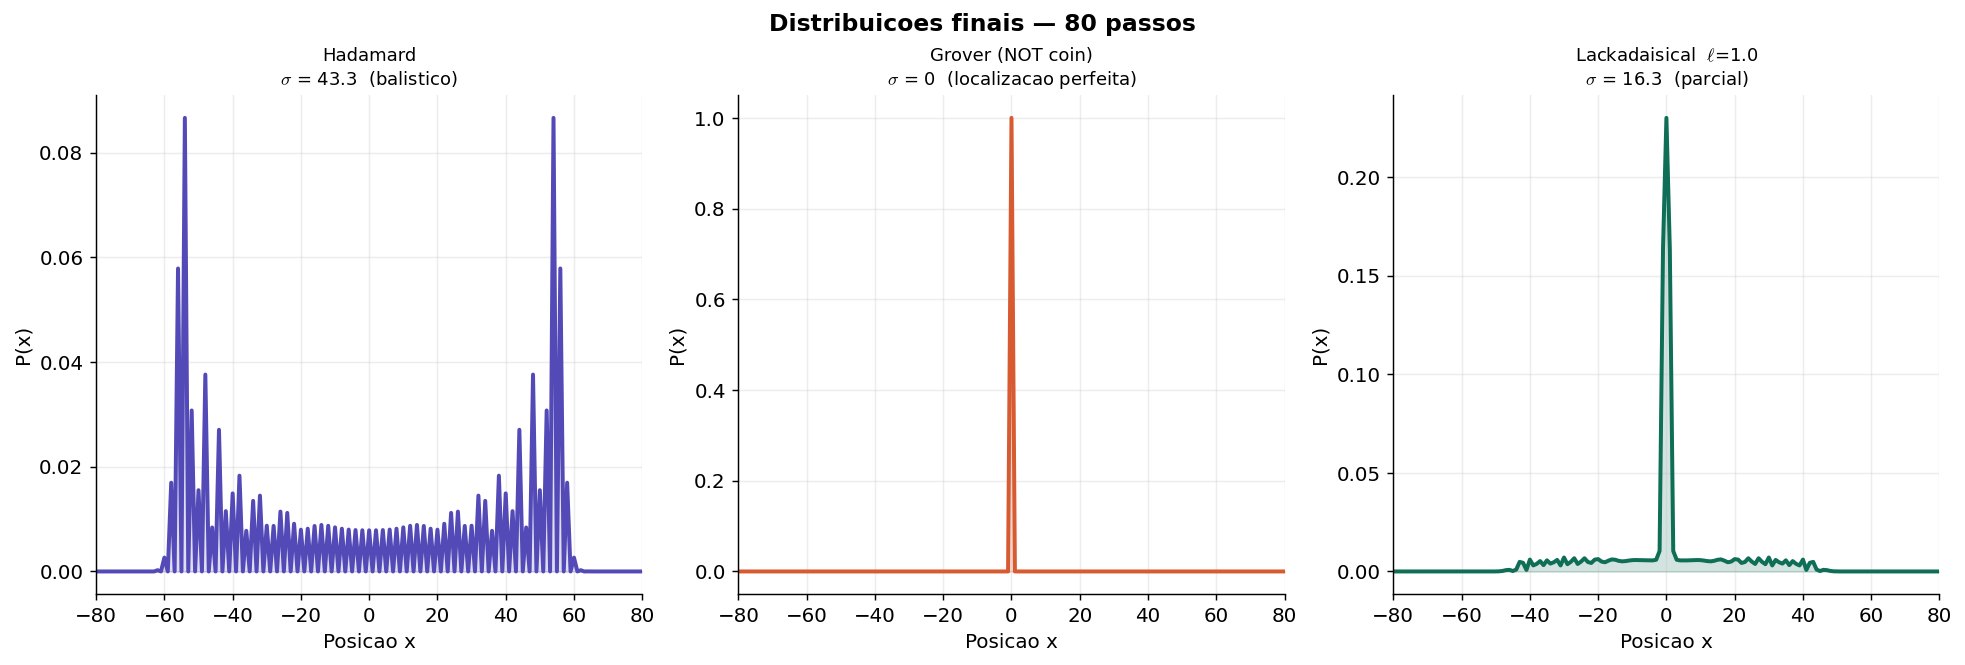

Salvo: coins_distributions.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

titles = {
    "hadamard":      f"Hadamard\n$\\sigma$ = {results['hadamard']['spreads'][-1]:.1f}  (balistico)",
    "grover":        f"Grover (NOT coin)\n$\\sigma$ = 0  (localizacao perfeita)",
    "lackadaisical": f"Lackadaisical  $\\ell$={L_LACKA}\n$\\sigma$ = {results['lackadaisical']['spreads'][-1]:.1f}  (parcial)",
}

for ax, name in zip(axes, ["hadamard","grover","lackadaisical"]):
    r   = results[name]
    col = COLOR[name]
    ax.fill_between(r["positions"], r["prob"], alpha=0.18, color=col)
    ax.plot(r["positions"], r["prob"], color=col, lw=2.2)
    ax.set_xlabel("Posicao x")
    ax.set_ylabel("P(x)")
    ax.set_title(titles[name], fontsize=10)
    ax.set_xlim(-N_STEPS, N_STEPS)

plt.suptitle(f"Distribuicoes finais — {N_STEPS} passos", fontsize=13, fontweight="bold")
plt.savefig("coins_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: coins_distributions.png")


## 7. Distribuições sobrepostas + zoom na origem

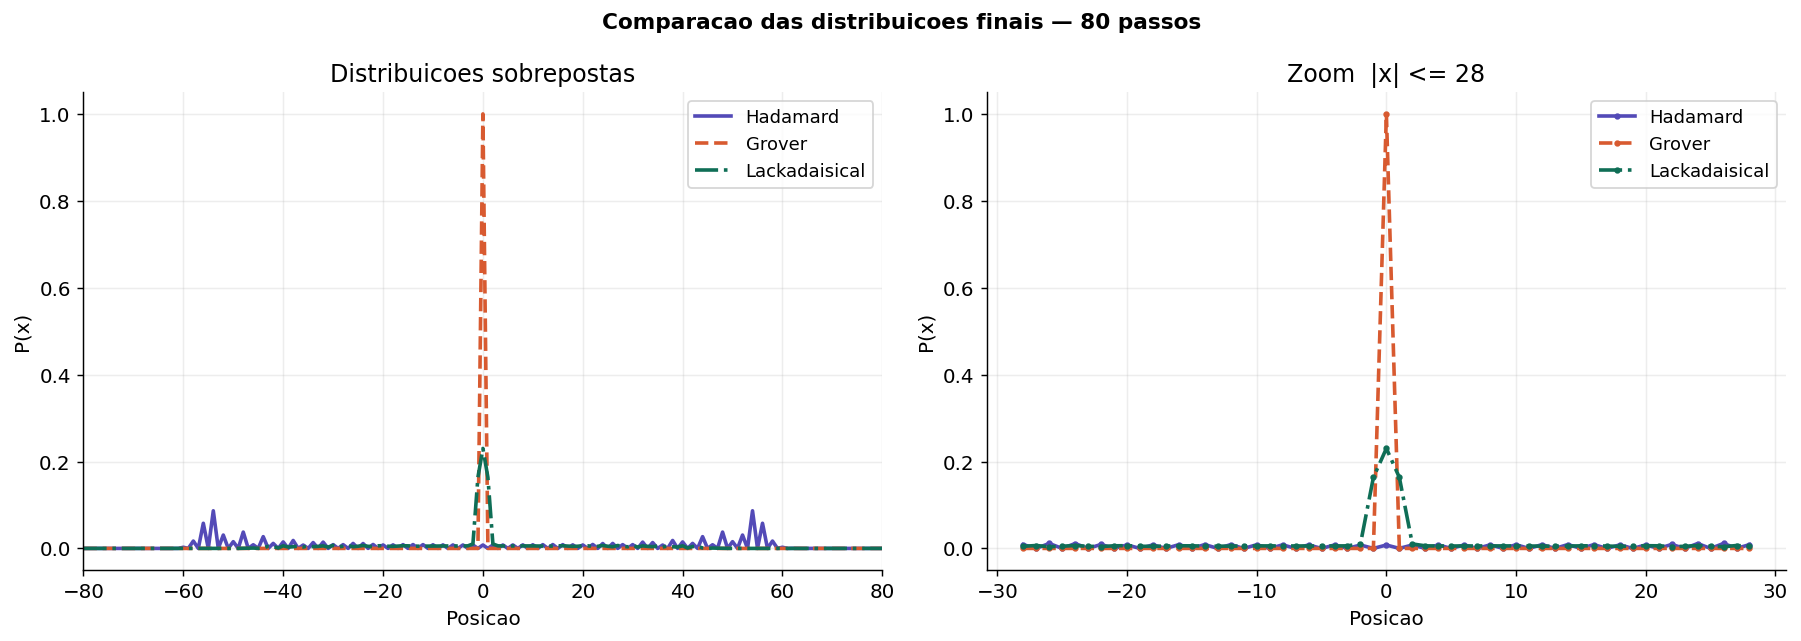

Salvo: coins_overlap.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name in ["hadamard","grover","lackadaisical"]:
    r = results[name]
    axes[0].plot(r["positions"], r["prob"], color=COLOR[name],
                 ls=LS[name], lw=2.0, label=name.capitalize())
axes[0].set_xlabel("Posicao"); axes[0].set_ylabel("P(x)")
axes[0].set_title("Distribuicoes sobrepostas"); axes[0].set_xlim(-N_STEPS, N_STEPS)
axes[0].legend(fontsize=10)

zoom = int(N_STEPS * 0.35)
for name in ["hadamard","grover","lackadaisical"]:
    r = results[name]
    mask = np.abs(r["positions"]) <= zoom
    axes[1].plot(r["positions"][mask], r["prob"][mask],
                 color=COLOR[name], ls=LS[name], lw=2.0,
                 marker="o", ms=2.5, label=name.capitalize())
axes[1].set_xlabel("Posicao"); axes[1].set_ylabel("P(x)")
axes[1].set_title(f"Zoom  |x| <= {zoom}")
axes[1].legend(fontsize=10)

plt.suptitle(f"Comparacao das distribuicoes finais — {N_STEPS} passos",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("coins_overlap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: coins_overlap.png")


## 8. Evolução temporal: $\sigma(t)$ e $P(x=0, t)$

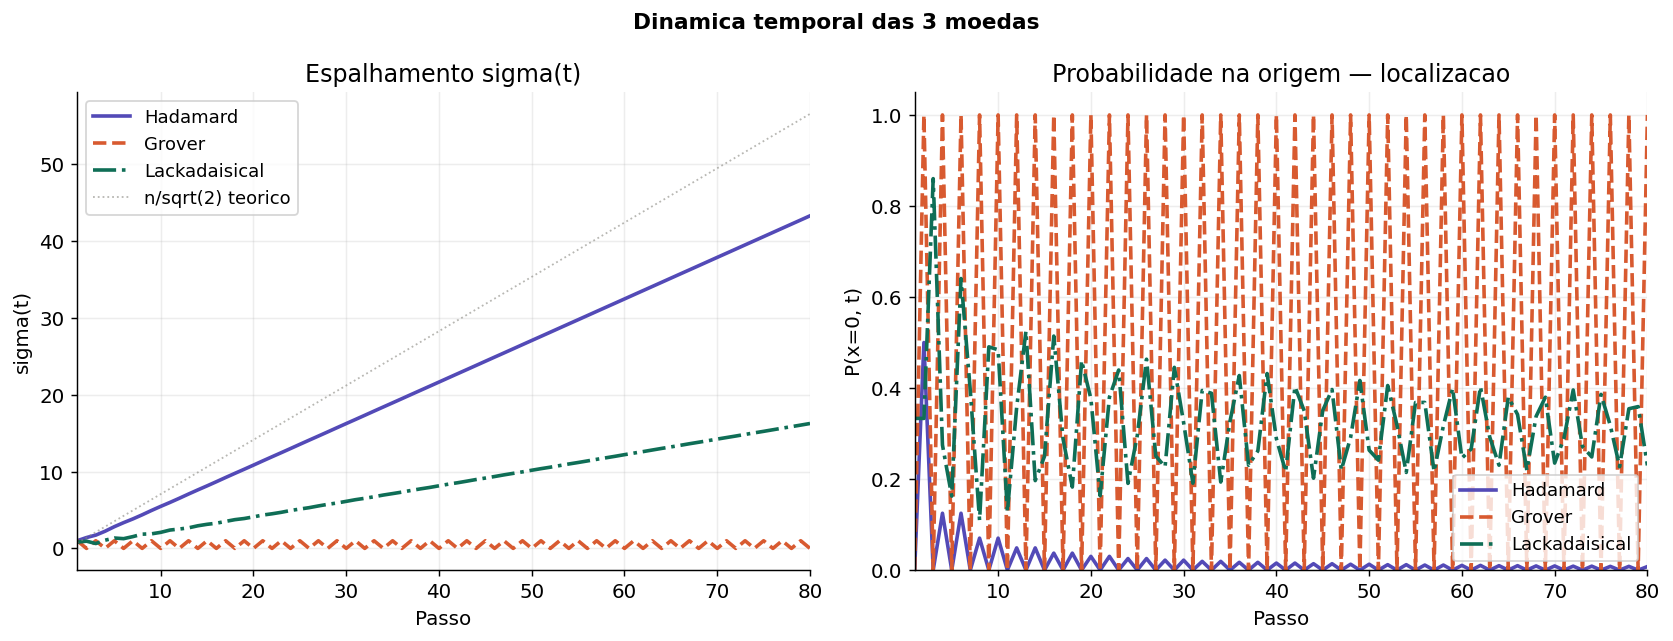

Salvo: coins_dynamics.png


In [8]:
steps_arr = np.arange(1, N_STEPS + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Espalhamento
for name in ["hadamard","grover","lackadaisical"]:
    axes[0].plot(steps_arr, results[name]["spreads"],
                 color=COLOR[name], ls=LS[name], lw=2.0, label=name.capitalize())
axes[0].plot(steps_arr, steps_arr/SQ2, color="#888780", lw=1.0, ls=":", alpha=0.6,
             label="n/sqrt(2) teorico")
axes[0].set_xlabel("Passo"); axes[0].set_ylabel("sigma(t)")
axes[0].set_title("Espalhamento sigma(t)")
axes[0].set_xlim(1, N_STEPS); axes[0].legend(fontsize=10)

# Localizacao
for name in ["hadamard","grover","lackadaisical"]:
    axes[1].plot(steps_arr, results[name]["loc_prob"],
                 color=COLOR[name], ls=LS[name], lw=2.0, label=name.capitalize())
axes[1].set_xlabel("Passo"); axes[1].set_ylabel("P(x=0, t)")
axes[1].set_title("Probabilidade na origem — localizacao")
axes[1].set_xlim(1, N_STEPS); axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=10)

plt.suptitle("Dinamica temporal das 3 moedas", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("coins_dynamics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: coins_dynamics.png")


## 9. Heatmap de evolução $P(x, t)$

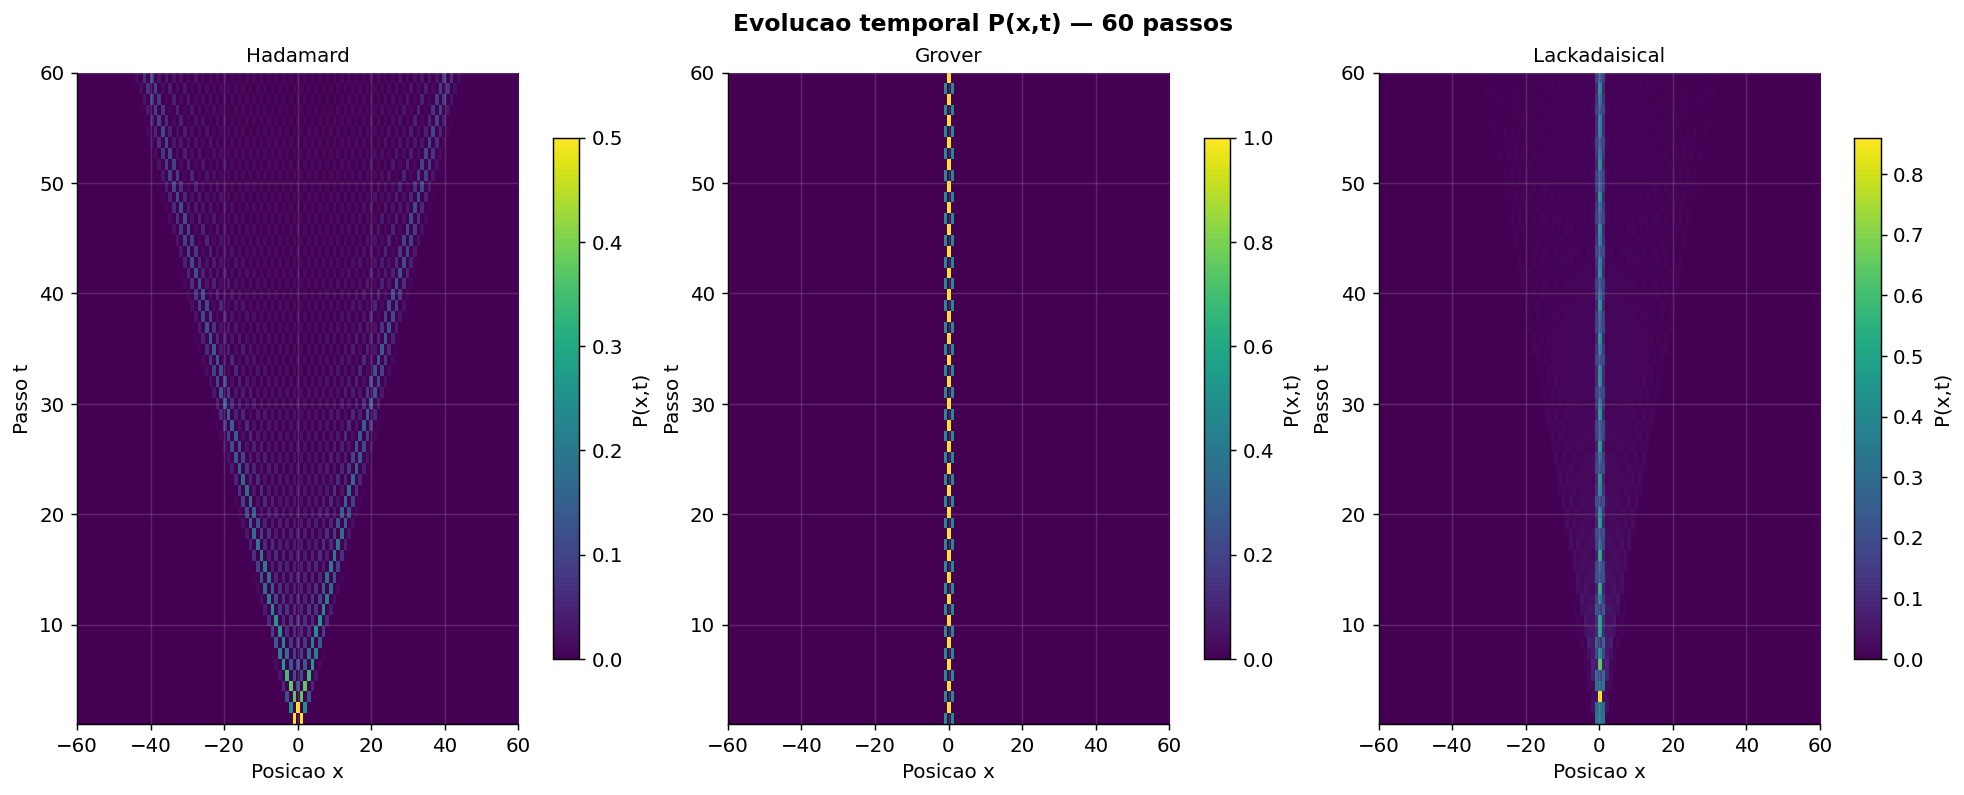

Salvo: coins_heatmap.png


In [9]:
def run_history(name, n_steps, l=1.0):
    """Re-simula e coleta P(x,t) a cada passo."""
    N = 2*n_steps + 1; c = n_steps
    if name == "hadamard":
        psi = np.zeros((N,2),dtype=complex); psi[c]=[1/SQ2,1j/SQ2]
        C, shift = H, shift_2d
    elif name == "grover":
        psi = np.zeros((N,2),dtype=complex); psi[c]=[1/SQ2,1j/SQ2]
        C, shift = G2, shift_2d
    else:
        Cl, v = lackadaisical_coin(l)
        psi = np.zeros((N,3),dtype=complex); psi[c]=v
        C, shift = Cl, shift_3d
    hist = []
    for _ in range(n_steps):
        psi = coin_apply(C, psi); psi = shift(psi)
        hist.append(np.sum(np.abs(psi)**2, axis=1).copy())
    return np.array(hist), np.arange(N)-c

N_HM = min(N_STEPS, 60)

fig, axes = plt.subplots(1, 3, figsize=(15, 6), constrained_layout=True)

for ax, name in zip(axes, ["hadamard","grover","lackadaisical"]):
    hist, pos_hm = run_history(name, N_HM, L_LACKA)
    im = ax.imshow(hist, aspect="auto", origin="lower",
                   extent=[pos_hm[0], pos_hm[-1], 1, N_HM],
                   cmap="viridis", interpolation="nearest")
    plt.colorbar(im, ax=ax, label="P(x,t)", shrink=0.8)
    ax.set_xlabel("Posicao x"); ax.set_ylabel("Passo t")
    ax.set_title(name.capitalize(), fontsize=11)

plt.suptitle(f"Evolucao temporal P(x,t) — {N_HM} passos",
             fontsize=13, fontweight="bold")
plt.savefig("coins_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: coins_heatmap.png")


## 10. Entropia de von Neumann da moeda

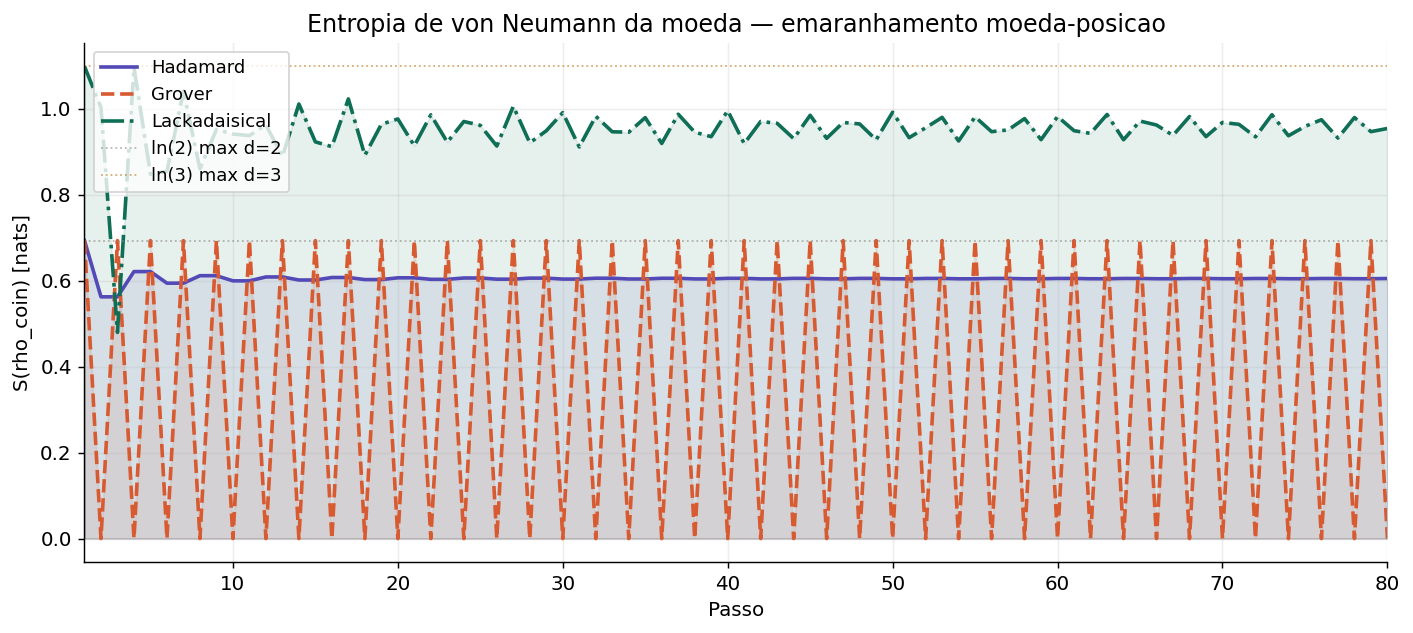

Salvo: coins_entropy.png


In [10]:
def entropy_coin(name, n_steps, l=1.0):
    """S(rho_coin) = -Tr(rho_c ln rho_c) a cada passo."""
    N = 2*n_steps+1; c = n_steps
    if name == "hadamard":
        psi=np.zeros((N,2),dtype=complex); psi[c]=[1/SQ2,1j/SQ2]; C=H; shift=shift_2d
    elif name == "grover":
        psi=np.zeros((N,2),dtype=complex); psi[c]=[1/SQ2,1j/SQ2]; C=G2; shift=shift_2d
    else:
        Cl,v=lackadaisical_coin(l)
        psi=np.zeros((N,3),dtype=complex); psi[c]=v; C=Cl; shift=shift_3d
    ents = []
    for _ in range(n_steps):
        psi=coin_apply(C,psi); psi=shift(psi)
        rho_c = np.einsum("xi,xj->ij", psi, psi.conj())
        eigs  = eigvalsh(rho_c).real
        eigs  = eigs[eigs > 1e-15]
        ents.append(float(-np.sum(eigs*np.log(eigs))))
    return np.array(ents)

ent_h = entropy_coin("hadamard",      N_STEPS)
ent_g = entropy_coin("grover",        N_STEPS)
ent_l = entropy_coin("lackadaisical", N_STEPS, L_LACKA)

fig, ax = plt.subplots(figsize=(11, 5))

for ent, name in [(ent_h,"hadamard"),(ent_g,"grover"),(ent_l,"lackadaisical")]:
    ax.fill_between(steps_arr, ent, alpha=0.10, color=COLOR[name])
    ax.plot(steps_arr, ent, color=COLOR[name], ls=LS[name], lw=2.0, label=name.capitalize())

ax.axhline(LN2,       color="#888780", lw=1.0, ls=":", alpha=0.6, label=f"ln(2) max d=2")
ax.axhline(np.log(3), color="#BA7517", lw=1.0, ls=":", alpha=0.6, label=f"ln(3) max d=3")

ax.set_xlabel("Passo"); ax.set_ylabel("S(rho_coin) [nats]")
ax.set_title("Entropia de von Neumann da moeda — emaranhamento moeda-posicao")
ax.set_xlim(1, N_STEPS); ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("coins_entropy.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: coins_entropy.png")


## 11. Scan do parâmetro $\ell$

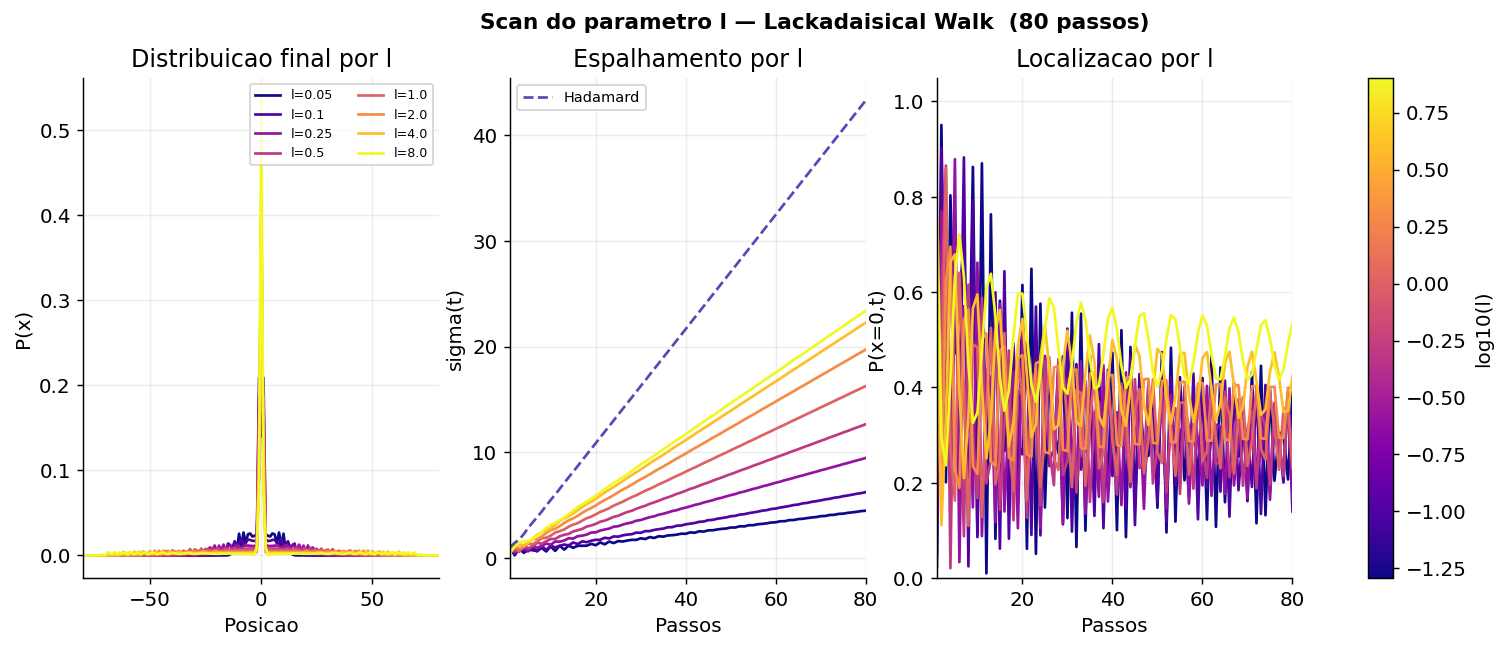

Salvo: coins_lacka_scan.png


In [11]:
scan_results = {}
for l in L_SCAN:
    scan_results[l] = walk_lackadaisical(N_STEPS, l)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

cmap_l = plt.cm.plasma
l_arr  = np.array(L_SCAN)
norm_l = plt.Normalize(np.log10(l_arr.min()+1e-3), np.log10(l_arr.max()))

for l in L_SCAN:
    r   = scan_results[l]
    col = cmap_l(norm_l(np.log10(l+1e-3)))
    axes[0].plot(r["positions"], r["prob"], color=col, lw=1.5, label=f"l={l}")
    axes[1].plot(steps_arr, r["spreads"],  color=col, lw=1.5)
    axes[2].plot(steps_arr, r["loc_prob"], color=col, lw=1.5)

for ax in axes:
    ax.set_xlabel("Passos" if ax != axes[0] else "Posicao")
axes[0].set_ylabel("P(x)"); axes[0].set_title("Distribuicao final por l")
axes[0].set_xlim(-N_STEPS, N_STEPS); axes[0].legend(fontsize=7, ncol=2)

axes[1].plot(steps_arr, results["hadamard"]["spreads"],
             color=COLOR["hadamard"], lw=1.5, ls="--", label="Hadamard")
axes[1].set_ylabel("sigma(t)"); axes[1].set_title("Espalhamento por l")
axes[1].set_xlim(1,N_STEPS); axes[1].legend(fontsize=8)

axes[2].set_ylabel("P(x=0,t)"); axes[2].set_title("Localizacao por l")
axes[2].set_xlim(1,N_STEPS); axes[2].set_ylim(0,1.05)

sm_l = plt.cm.ScalarMappable(cmap=cmap_l, norm=norm_l)
plt.colorbar(sm_l, ax=axes, label="log10(l)")
plt.suptitle(f"Scan do parametro l — Lackadaisical Walk  ({N_STEPS} passos)",
             fontsize=12, fontweight="bold")
plt.savefig("coins_lacka_scan.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: coins_lacka_scan.png")


## 12. Scan: métricas em função do número de passos

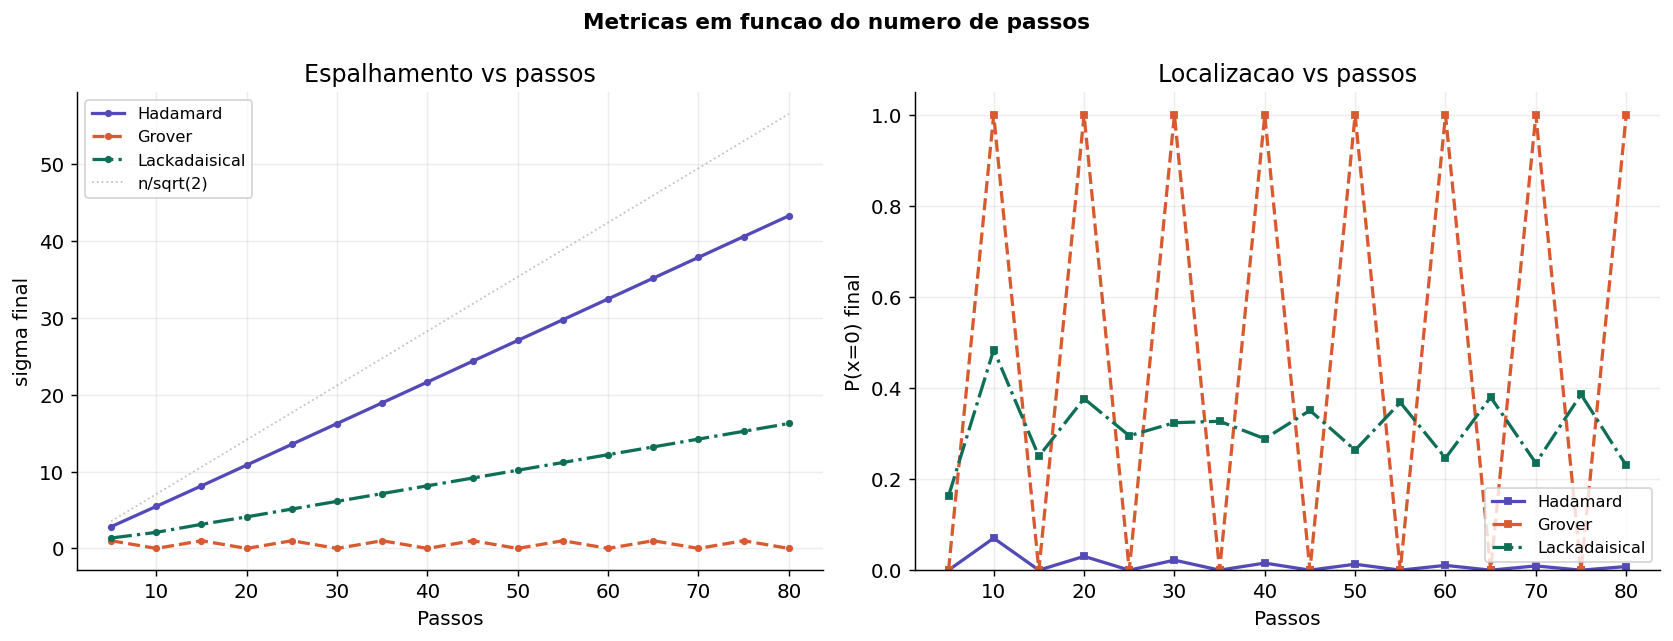

Salvo: coins_scan_steps.png


In [12]:
step_range = np.arange(5, N_STEPS+1, 5)
metrics = {n: {"spread":[], "loc":[]} for n in ["hadamard","grover","lackadaisical"]}

for ns in step_range:
    for name, fn in [("hadamard", lambda ns=ns: walk_hadamard(ns)),
                     ("grover",   lambda ns=ns: walk_grover(ns)),
                     ("lackadaisical", lambda ns=ns: walk_lackadaisical(ns, L_LACKA))]:
        r = fn()
        metrics[name]["spread"].append(r["spreads"][-1])
        metrics[name]["loc"].append(r["loc_prob"][-1])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name in ["hadamard","grover","lackadaisical"]:
    axes[0].plot(step_range, metrics[name]["spread"],
                 color=COLOR[name], ls=LS[name], lw=1.8, marker="o", ms=3,
                 label=name.capitalize())
    axes[1].plot(step_range, metrics[name]["loc"],
                 color=COLOR[name], ls=LS[name], lw=1.8, marker="s", ms=3,
                 label=name.capitalize())

axes[0].plot(step_range, step_range/SQ2, color="#888780", lw=1, ls=":", alpha=0.5,
             label="n/sqrt(2)")
axes[0].set_xlabel("Passos"); axes[0].set_ylabel("sigma final")
axes[0].set_title("Espalhamento vs passos"); axes[0].legend(fontsize=9)
axes[1].set_xlabel("Passos"); axes[1].set_ylabel("P(x=0) final")
axes[1].set_title("Localizacao vs passos"); axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 1.05)

plt.suptitle("Metricas em funcao do numero de passos",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("coins_scan_steps.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: coins_scan_steps.png")


## 13. Painel executivo — resumo completo

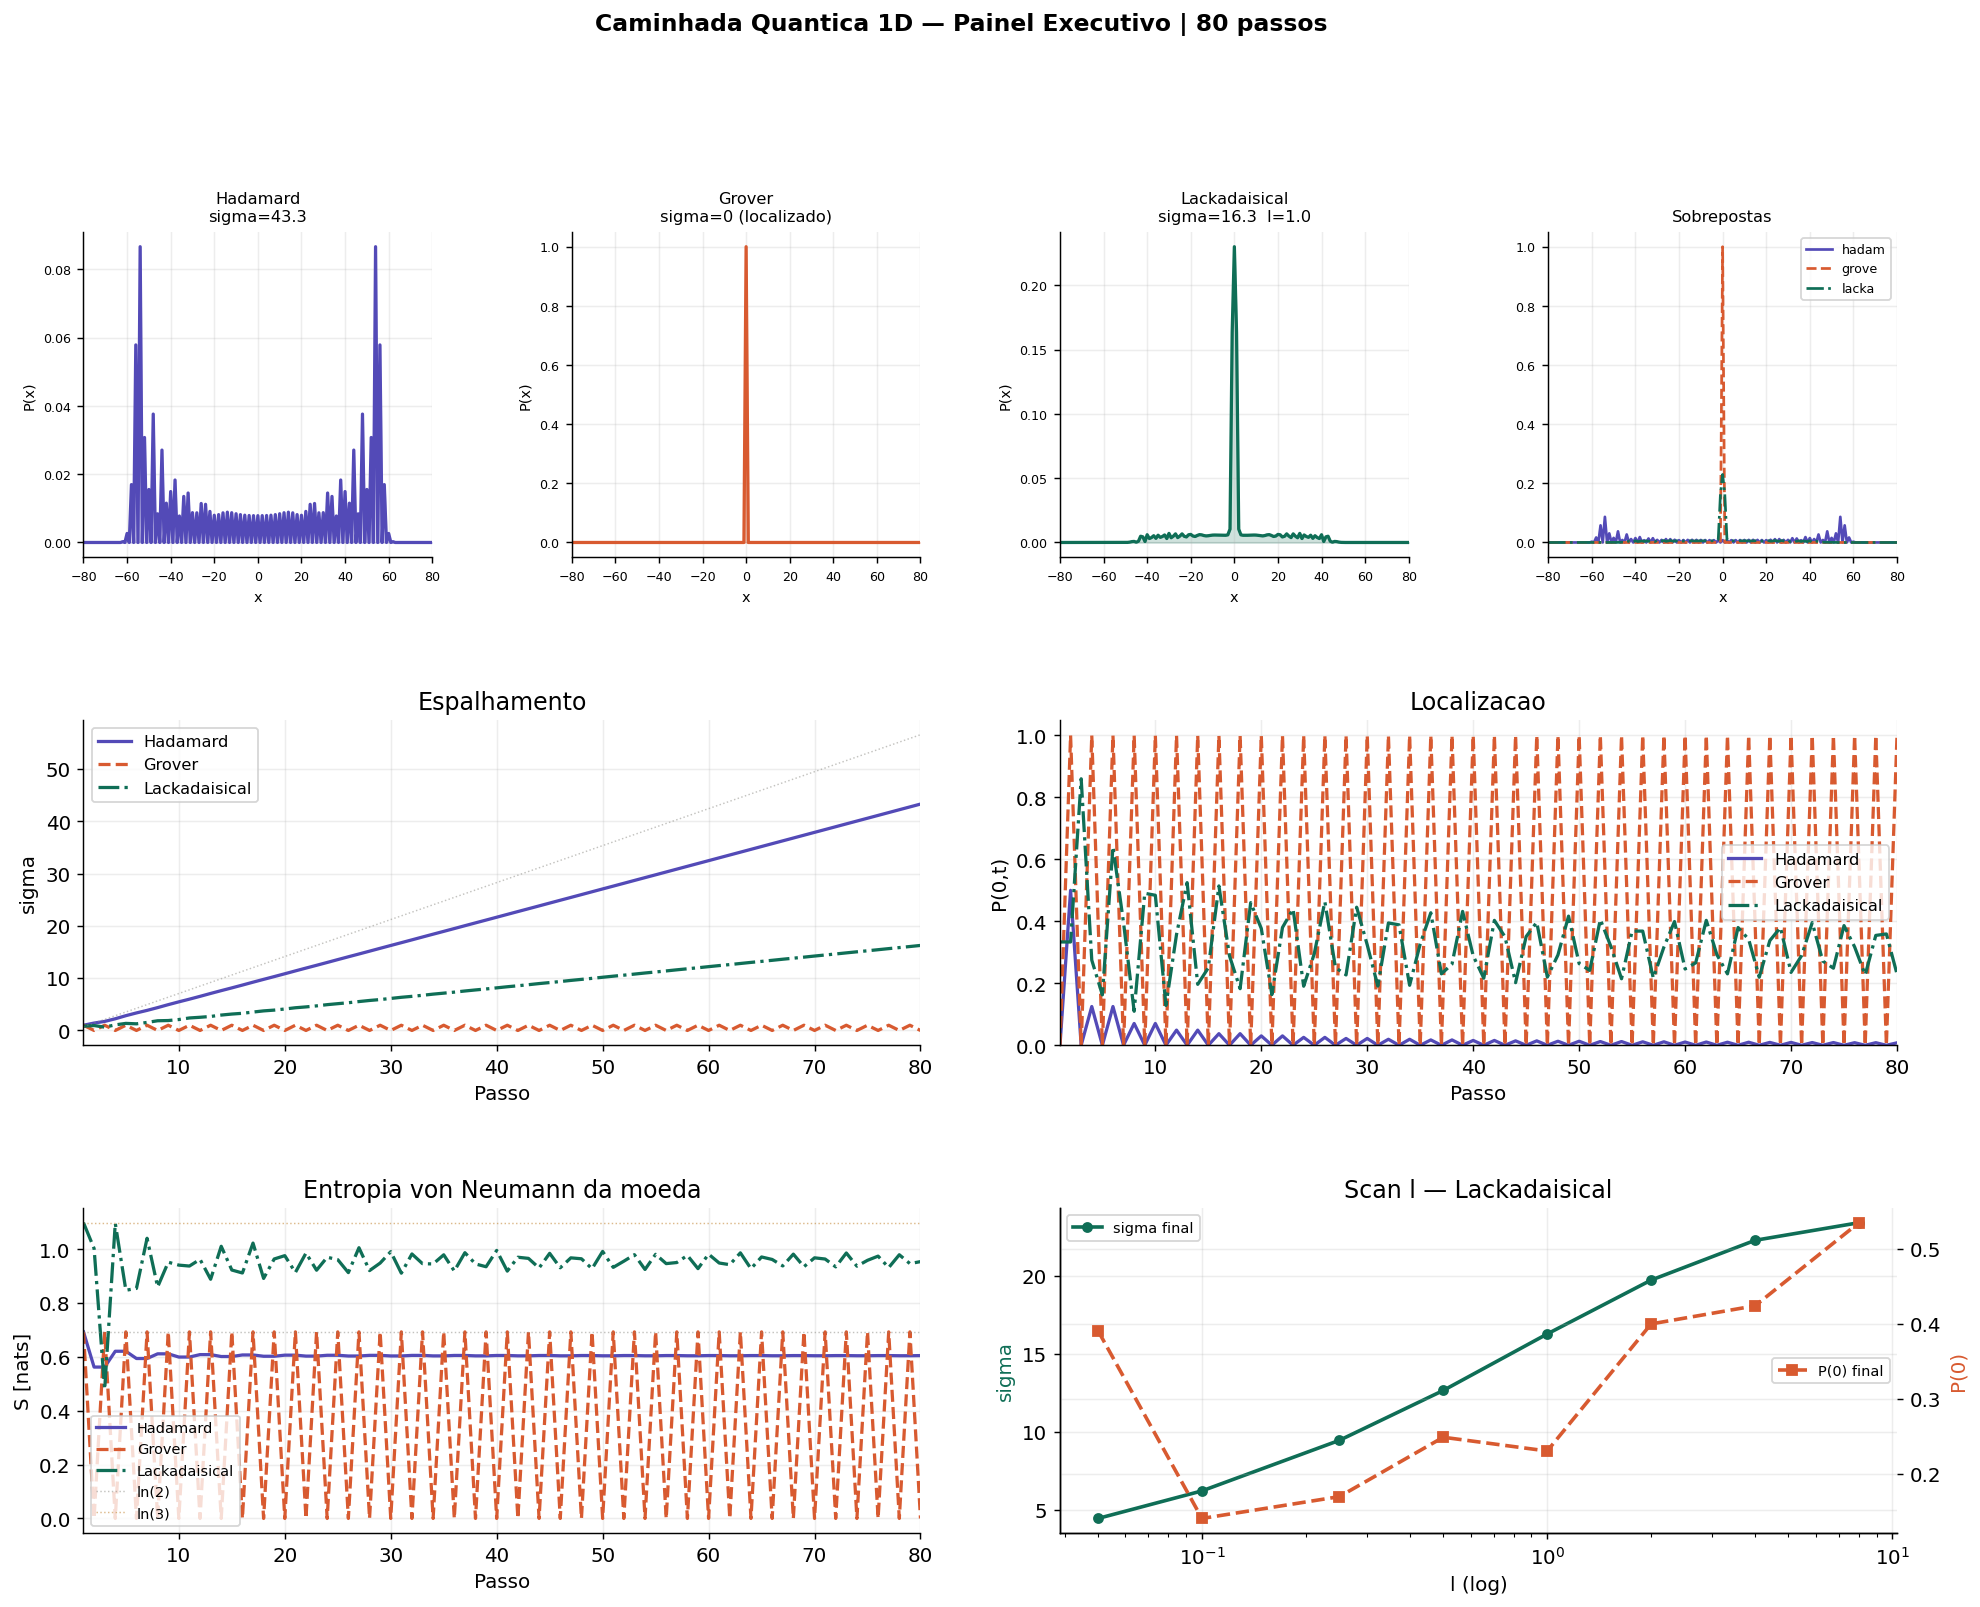

Salvo: coins_dashboard.png


In [13]:
steps_arr = np.arange(1, N_STEPS+1)
fig = plt.figure(figsize=(18, 13))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.50, wspace=0.40)

ax_hd = fig.add_subplot(gs[0, 0])
ax_gr = fig.add_subplot(gs[0, 1])
ax_la = fig.add_subplot(gs[0, 2])
ax_ov = fig.add_subplot(gs[0, 3])
ax_sp = fig.add_subplot(gs[1, 0:2])
ax_lo = fig.add_subplot(gs[1, 2:4])
ax_en = fig.add_subplot(gs[2, 0:2])
ax_sc = fig.add_subplot(gs[2, 2:4])

# Distribuicoes individuais
subtitles = {
    "hadamard":      f"sigma={results['hadamard']['spreads'][-1]:.1f}",
    "grover":        "sigma=0 (localizado)",
    "lackadaisical": f"sigma={results['lackadaisical']['spreads'][-1]:.1f}  l={L_LACKA}",
}
for ax, name in [(ax_hd,"hadamard"),(ax_gr,"grover"),(ax_la,"lackadaisical")]:
    r = results[name]
    ax.fill_between(r["positions"], r["prob"], alpha=0.2, color=COLOR[name])
    ax.plot(r["positions"], r["prob"], color=COLOR[name], lw=1.8)
    ax.set_title(f"{name.capitalize()}\n{subtitles[name]}", fontsize=9)
    ax.set_xlabel("x", fontsize=8); ax.set_ylabel("P(x)", fontsize=8)
    ax.tick_params(labelsize=7); ax.set_xlim(-N_STEPS, N_STEPS)

# Sobrepostas
for name in ["hadamard","grover","lackadaisical"]:
    r = results[name]
    ax_ov.plot(r["positions"], r["prob"], color=COLOR[name],
               ls=LS[name], lw=1.5, label=name[:5])
ax_ov.set_title("Sobrepostas", fontsize=9)
ax_ov.set_xlabel("x", fontsize=8); ax_ov.set_xlim(-N_STEPS, N_STEPS)
ax_ov.legend(fontsize=7); ax_ov.tick_params(labelsize=7)

# Spread e localizacao
for name in ["hadamard","grover","lackadaisical"]:
    ax_sp.plot(steps_arr, results[name]["spreads"],
               color=COLOR[name], ls=LS[name], lw=1.8, label=name.capitalize())
    ax_lo.plot(steps_arr, results[name]["loc_prob"],
               color=COLOR[name], ls=LS[name], lw=1.8, label=name.capitalize())
ax_sp.plot(steps_arr, steps_arr/SQ2, color="#888780", lw=0.8, ls=":", alpha=0.5)
ax_sp.set_xlabel("Passo"); ax_sp.set_ylabel("sigma"); ax_sp.set_title("Espalhamento")
ax_sp.legend(fontsize=9); ax_sp.set_xlim(1,N_STEPS)
ax_lo.set_xlabel("Passo"); ax_lo.set_ylabel("P(0,t)"); ax_lo.set_title("Localizacao")
ax_lo.legend(fontsize=9); ax_lo.set_xlim(1,N_STEPS); ax_lo.set_ylim(0,1.05)

# Entropia
for ent, name in [(ent_h,"hadamard"),(ent_g,"grover"),(ent_l,"lackadaisical")]:
    ax_en.plot(steps_arr, ent, color=COLOR[name], ls=LS[name], lw=1.8, label=name.capitalize())
ax_en.axhline(LN2, color="#888780", lw=0.8, ls=":", alpha=0.5, label="ln(2)")
ax_en.axhline(np.log(3), color="#BA7517", lw=0.8, ls=":", alpha=0.5, label="ln(3)")
ax_en.set_xlabel("Passo"); ax_en.set_ylabel("S [nats]")
ax_en.set_title("Entropia von Neumann da moeda")
ax_en.legend(fontsize=8); ax_en.set_xlim(1,N_STEPS)

# Scan l (sigma e P(0))
l_vals  = np.array(L_SCAN)
sp_vals = [scan_results[l]["spreads"][-1] for l in L_SCAN]
lo_vals = [scan_results[l]["loc_prob"][-1] for l in L_SCAN]
ax_sc.semilogx(l_vals, sp_vals, color=COLOR["lackadaisical"], lw=2, marker="o", ms=5,
               label="sigma final")
ax_sc2 = ax_sc.twinx()
ax_sc2.semilogx(l_vals, lo_vals, color=COLOR["grover"], lw=2, ls="--",
                marker="s", ms=5, label="P(0) final")
ax_sc.set_xlabel("l (log)"); ax_sc.set_ylabel("sigma", color=COLOR["lackadaisical"])
ax_sc2.set_ylabel("P(0)", color=COLOR["grover"])
ax_sc.set_title("Scan l — Lackadaisical")
ax_sc.legend(loc="upper left", fontsize=8); ax_sc2.legend(loc="center right", fontsize=8)

plt.suptitle(f"Caminhada Quantica 1D — Painel Executivo | {N_STEPS} passos",
             fontsize=13, fontweight="bold", y=1.01)
plt.savefig("coins_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: coins_dashboard.png")


## 14. Resumo numérico

In [14]:
print("=" * 76)
print(f"{'Moeda':18s} {'sigma':>8} {'sigma_teo':>10} {'P(x=0)':>8} {'S_coin_fin':>12} {'dim':>5}")
print("-" * 76)

rows = [
    ("hadamard",      ent_h, results["hadamard"],      N_STEPS/SQ2, 2),
    ("grover",        ent_g, results["grover"],         0.0,         2),
    ("lackadaisical", ent_l, results["lackadaisical"],  None,        3),
]
for name, ent, r, teo, d in rows:
    s   = r["spreads"][-1]
    p0  = r["loc_prob"][-1]
    sco = ent[-1]
    ts  = f"{teo:.4f}" if teo is not None else "N/A"
    print(f"{name:18s} {s:>8.4f} {ts:>10} {p0:>8.4f} {sco:>12.6f} {d:>5d}")

print("-" * 76)
print()
print("Scan Lackadaisical:")
print(f"  {'l':>6} {'sigma':>9} {'P(x=0)':>9}")
for l in L_SCAN:
    r = scan_results[l]
    print(f"  {l:>6.2f} {r['spreads'][-1]:>9.4f} {r['loc_prob'][-1]:>9.4f}")
print()
print(f"ln(2) = {LN2:.6f}  |  ln(3) = {np.log(3):.6f}  |  N = {N_STEPS}")


Moeda                 sigma  sigma_teo   P(x=0)   S_coin_fin   dim
----------------------------------------------------------------------------
hadamard            43.3013    56.5685   0.0079     0.604965     2
grover               0.0000     0.0000   1.0000     0.000000     2
lackadaisical       16.2633        N/A   0.2301     0.954022     3
----------------------------------------------------------------------------

Scan Lackadaisical:
       l     sigma    P(x=0)
    0.05    4.4546    0.3908
    0.10    6.2190    0.1399
    0.25    9.4535    0.1691
    0.50   12.6481    0.2485
    1.00   16.2633    0.2301
    2.00   19.7128    0.3999
    4.00   22.2592    0.4241
    8.00   23.3877    0.5352

ln(2) = 0.693147  |  ln(3) = 1.098612  |  N = 80
